## 4L(2) Remote content duration

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.changeOfMind_figures.figure4 import (long_theta_count_per_day, intersection,
            return_com_theta_length_remote_feature)
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features
from spyglass.shijiegu.Analysis_SGU import ChangeofMind

from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess

from spyglass.shijiegu.changeOfMind_remote_interval import save_remote_animal, load_remote_animal

[2026-01-21 14:26:29,929][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[14:26:39][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:26:39][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:26:39][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:26:40][WARNING] Spyglass: Deprecation: this class has b

In [4]:
list_of_days_animals = {}

In [5]:
list_of_days_animals = {}
success_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']

In [6]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta

In [9]:
success = {}
long_duration = {}
remote_duration = {}

#parameter_name_long_theta = "params_both_max_segment_all_maze_2_state"
#parameter_name_remote = "params_both_max_all_maze_2_state"#"params_both_max_run_time_2_state" #"params_both_max_all_maze_2_state"  #"params_both_max_run_time_2_state"

decode_name_long = "params_both_max_segment_run_time_2_state"
decode_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
proportion = 0.1
hpd = False

local_parameter = f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"
remote_parameter = f"dur_{minimum_duration_remote}_sum_{min_posterior}"

for animal in ["molly","klein","eliot","julio","lewis"]:
    # trials with either long theta or remote theta
    
    # loop through all trials
    list_of_days = list_of_days_animals[animal]
    
    long_duration[animal] = []
    remote_duration[animal] = []
    
    for day_ind in range(len(list_of_days)):
        day = list_of_days[day_ind]
        
        nwb_file_name = animal.lower() + day + '.nwb'
        nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
        print(nwb_copy_file_name)
        session_interval, position_interval = runSessionNames(nwb_copy_file_name)
            
        q_long = {"proportion": proportion,
                  "parameter":decode_name_long,
                 "local_parameter":local_parameter,
                 }

        q_long["nwb_file_name"] = nwb_copy_file_name
        q_remote = q_long.copy()
        q_remote["parameter"] = decode_name_remote
        q_remote["remote_parameter"] = remote_parameter
    
        for session_name in session_interval:
            q_long["epoch"] = int(session_name[:2])
            q_remote["epoch"] = int(session_name[:2])
            
            if len(ChangeofMindTheta() & q_long) == 0:
                continue
                
            if len(ChangeofMindRemoteTheta() & q_remote) == 0:
                continue
            long_df = ChangeofMindTheta().fetch1_dataframe(q_long)         # trials with long theta
            remote_df = ChangeofMindRemoteTheta().fetch1_dataframe(q_remote) # trials with remote theta for now
    
            # long trials
            long_df = long_df[long_df.long_theta]
            for trialID in long_df.index:
                for intvl in long_df.loc[trialID].long_theta_intervals:
                    long_duration[animal].append(intvl[1] - intvl[0])

            # remote event
            remote_df = remote_df[remote_df.has_remote_interval]
            for trialID in remote_df.index:
                for intvl in remote_df.loc[trialID].remote_interval:
                    remote_duration[animal].append(intvl[1] - intvl[0])
        
    success[animal] = 1


molly20220415_.nwb
molly20220416_.nwb
molly20220417_.nwb
molly20220418_.nwb
molly20220419_.nwb
molly20220420_.nwb
klein20231101_.nwb
klein20231102_.nwb
klein20231103_.nwb
klein20231104_.nwb
klein20231105_.nwb
klein20231106_.nwb
klein20231107_.nwb
klein20231108_.nwb
eliot20221018_.nwb
eliot20221019_.nwb
eliot20221020_.nwb
eliot20221021_.nwb
eliot20221022_.nwb
eliot20221023_.nwb
eliot20221024_.nwb
eliot20221025_.nwb
eliot20221026_.nwb
julio20230731_.nwb
julio20230801_.nwb
julio20230802_.nwb
julio20230803_.nwb
julio20230804_.nwb
julio20230805_.nwb
julio20230806_.nwb
julio20230807_.nwb
julio20230808_.nwb
julio20230809_.nwb
julio20230810_.nwb
julio20230811_.nwb
lewis20240105_.nwb
lewis20240106_.nwb
lewis20240107_.nwb
lewis20240108_.nwb
lewis20240109_.nwb
lewis20240110_.nwb


### Plotting

In [16]:
from spyglass.shijiegu.changeOfMind import color_by_rat

In [21]:
long_duration[animal]

[0.07399988174438477,
 0.08999991416931152,
 0.06800007820129395,
 0.039999961853027344,
 0.03800010681152344,
 0.039999961853027344,
 0.039999961853027344,
 0.12000012397766113,
 0.029999971389770508,
 0.054000139236450195,
 0.04999995231628418,
 0.04200005531311035,
 0.04800009727478027,
 0.046000003814697266,
 0.07800006866455078,
 0.10199975967407227,
 0.06800007820129395,
 0.08599996566772461,
 0.08800005912780762,
 0.037999868392944336,
 0.06200003623962402,
 0.06599998474121094,
 0.03399991989135742,
 0.12999987602233887,
 0.03600001335144043,
 0.09799981117248535,
 0.06800007820129395,
 0.14400005340576172,
 0.09399986267089844,
 0.03600001335144043,
 0.05200004577636719,
 0.04999995231628418,
 0.059999942779541016,
 0.03399991989135742,
 0.029999971389770508,
 0.04200005531311035,
 0.03600001335144043,
 0.037999868392944336,
 0.0839998722076416,
 0.11800003051757812,
 0.06999993324279785,
 0.07999992370605469,
 0.04800009727478027,
 0.03600001335144043,
 0.029999971389770508,


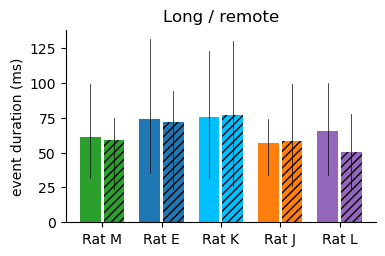

In [29]:
fig, axes = plt.subplots(1,1, figsize=(4, 2.5))

animals = ["molly","eliot", "klein", "julio","lewis"]

ax = axes
animal_ind = 0
annotations = []
for animal in animals:
    
    data1, data2 = np.array(long_duration[animal]) * 1000, np.array(remote_duration[animal]) * 1000
    
    # mean estmate
    data1_mean = np.nanmean(data1)
    data2_mean = np.nanmean(data2)

    # std
    alpha = 0.25
    l1, h1 = np.nanquantile(data1, alpha/2), np.nanquantile(data1, 1 - alpha/2)
    l2, h2 = np.nanquantile(data2, alpha/2), np.nanquantile(data2, 1 - alpha/2)
    
    xs = np.array([0, 0.4]) + (animal_ind)

    # mean and sd
    ax.bar(xs, [data1_mean, data2_mean], width=0.35, hatch=['', '////'], color = color_by_rat[animal])
    ax.plot([xs[0], xs[0]],[l1, h1], linewidth=0.5, color = 'k')
    ax.plot([xs[1], xs[1]],[l2, h2], linewidth=0.5, color = 'k')
    
    ax.set_ylabel("event duration (ms)")


    animal_ind += 1
    
ax.set_xticks(np.arange(animal_ind) + 0.2)
ax.set_xticklabels([f"Rat {animal[0].upper()}" for animal in animals])
ax.set_title("Long / remote")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_event_duration_summary.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

## End

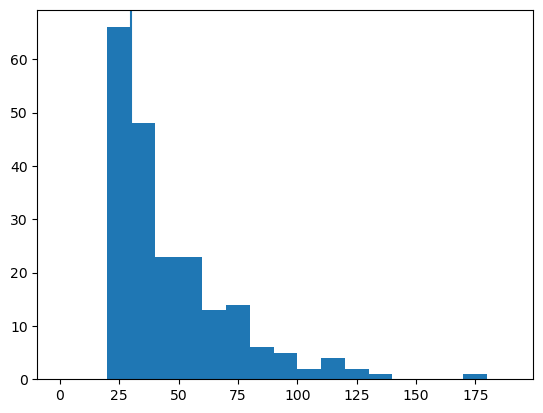

In [13]:
animal = "lewis"
plt.hist(np.array(remote_duration[animal])*1000, bins = np.arange(0,200,10))
plt.axvline(30)

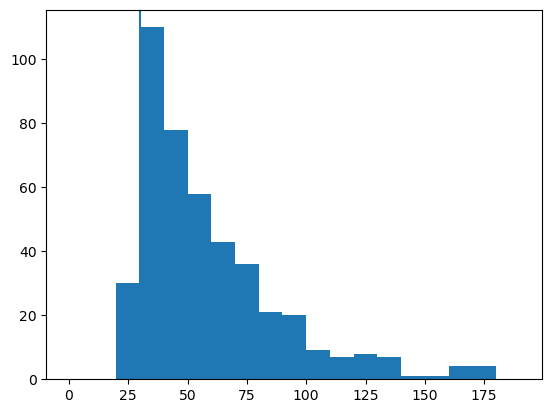

In [12]:
plt.hist(np.array(long_duration[animal])*1000, bins = np.arange(0,200,10))
plt.axvline(30)

In [11]:
long_df.loc[58].long_theta_intervals

[(1650304630.535302, 1650304630.555302),
 (1650304630.5973017, 1650304630.6273017)]